In [1]:
import json

with open("patients_ours.json") as f:
    patients_ours = json.load(f)

In [2]:
import os
import pandas

our_dataset_basepath = "nuclear-cataract-ours"
labels_path = os.path.join(our_dataset_basepath, "labels.json")
labels_df = pandas.read_json(labels_path)
print(len(labels_df))
labels_df

1339


,image,id,choice,annotator,annotation_id,created_at,updated_at,lead_time,label,Trudny przyklad
0,/data/upload/5/f93c5eb9-0a01f47d-6536-41d6-b38...,1064,Zdjęcie nieczytelne,2,5642,2025-11-16 19:15:12.824895+00:00,2025-11-16 19:15:12.824910+00:00,38.663,NaN,NaN
1,/data/upload/5/e158e27f-0a5f839b-5b16-4a0e-966...,1065,Zaćma,5,2876,2025-05-12 19:16:56.951117+00:00,2025-05-12 19:16:56.951138+00:00,22.825,"[{'x': 36.96513470681458, 'y': 19.175911251980...",NaN
2,/data/upload/5/261479ac-0a28bb30-2a20-4a0c-b61...,1066,Zaćma,5,2877,2025-05-12 19:17:36.947326+00:00,2025-05-12 19:17:36.947350+00:00,24.016,"[{'x': 33.874801901743275, 'y': 24.08874801901...",NaN
3,/data/upload/5/54146273-0a819ff8-1232-401c-9eb...,1067,Brak Zaćmy,5,2878,2025-05-12 19:17:49.778908+00:00,2025-05-12 19:17:49.778934+00:00,11.862,NaN,NaN
4,/data/upload/5/1f6b5b41-0a869ff0-2389-4b13-a73...,1068,Inne choroby,5,2879,2025-05-12 19:18:04.834997+00:00,2025-05-12 19:18:04.835017+00:00,13.995,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1334,/data/upload/5/f5e41dcd-IM000013.JPG,2398,Zaćma,5,5637,2025-10-09 18:13:30.618226+00:00,2025-10-09 18:13:30.618242+00:00,9.074,"[{'x': 65.13470681458003, 'y': 35.816164817749...",NaN
1335,/data/upload/5/f91b0f3d-IM000014.JPG,2399,Zaćma,5,5638,2025-10-09 18:13:41.921395+00:00,2025-10-09 18:13:41.921413+00:00,7.432,"[{'x': 69.4136291600634, 'y': 43.5816164817749...",NaN
1336,/data/upload/5/f3af51d7-IM000015.JPG,2400,NaN,5,5639,2025-10-09 18:14:09.607959+00:00,2025-10-09 18:14:09.607972+00:00,17.911,"[{'x': 57.88431061806657, 'y': 22.028526148969...",NaN
1337,/data/upload/5/1b232844-IM000016.JPG,2401,NaN,5,5640,2025-10-09 18:14:24.298702+00:00,2025-10-09 18:14:24.298721+00:00,13.058,"[{'x': 54.43740095087164, 'y': 22.503961965134...",NaN


In [3]:
labels_df = labels_df.dropna(subset=["choice"])
labels_df = labels_df[labels_df["choice"].map(lambda x: x not in ["Zdjęcie nieczytelne", "Inne choroby"])]
print(len(labels_df))

labels_df["choice"] = labels_df["choice"].apply(lambda x: "Brak Zaćmy" if x == "Zdrowe" else x).copy()
labels_df["image"] = labels_df["image"].apply(lambda x: os.path.basename(x)).copy()
print(labels_df["choice"].value_counts())
labels_df

1239
choice
Zaćma         861
Brak Zaćmy    378
Name: count, dtype: int64


,image,id,choice,annotator,annotation_id,created_at,updated_at,lead_time,label,Trudny przyklad
1,e158e27f-0a5f839b-5b16-4a0e-966e-52cc7d373c6d.jpg,1065,Zaćma,5,2876,2025-05-12 19:16:56.951117+00:00,2025-05-12 19:16:56.951138+00:00,22.825,"[{'x': 36.96513470681458, 'y': 19.175911251980...",NaN
2,261479ac-0a28bb30-2a20-4a0c-b610-9b3f667054c3.jpg,1066,Zaćma,5,2877,2025-05-12 19:17:36.947326+00:00,2025-05-12 19:17:36.947350+00:00,24.016,"[{'x': 33.874801901743275, 'y': 24.08874801901...",NaN
3,54146273-0a819ff8-1232-401c-9eba-5ef6c1ced3b9.jpg,1067,Brak Zaćmy,5,2878,2025-05-12 19:17:49.778908+00:00,2025-05-12 19:17:49.778934+00:00,11.862,NaN,NaN
5,e4024cd0-0a04786b-668a-4eaf-9752-2a3de3ec71d0.jpg,1069,Zaćma,5,2880,2025-05-12 19:18:59.508262+00:00,2025-05-12 19:18:59.508285+00:00,53.726,"[{'x': 17.828843106180667, 'y': 8.716323296354...",NaN
6,510afbfd-0a6323dd-8488-48cb-816c-7a6e589e04b4.jpg,1070,Zaćma,5,2881,2025-05-12 19:19:26.646584+00:00,2025-05-12 19:19:26.646606+00:00,26.192,"[{'x': 46.47385103011095, 'y': 21.553090332805...",NaN
...,...,...,...,...,...,...,...,...,...,...
1331,300a4438-IM000010.JPG,2395,Zaćma,5,5634,2025-10-09 18:12:48.421669+00:00,2025-10-09 18:12:54.209431+00:00,18.666,"[{'x': 26.148969889064976, 'y': 40.41204437400...",NaN
1332,a58fc387-IM000011.JPG,2396,Zaćma,5,5635,2025-10-09 18:13:07.673424+00:00,2025-10-09 18:13:07.673440+00:00,10.774,"[{'x': 31.141045958795566, 'y': 41.36291600633...",NaN
1333,602c8654-IM000012.JPG,2397,Zaćma,5,5636,2025-10-09 18:13:19.407125+00:00,2025-10-09 18:13:19.407140+00:00,9.469,"[{'x': 62.28209191759113, 'y': 38.193343898573...",NaN
1334,f5e41dcd-IM000013.JPG,2398,Zaćma,5,5637,2025-10-09 18:13:30.618226+00:00,2025-10-09 18:13:30.618242+00:00,9.074,"[{'x': 65.13470681458003, 'y': 35.816164817749...",NaN


In [4]:
def get_label_of(image_path: str):
    return labels_df[labels_df["image"] == image_path]["choice"].item()

In [5]:
get_label_of("e158e27f-0a5f839b-5b16-4a0e-966e-52cc7d373c6d.jpg")

'Zaćma'

In [6]:
import random

datapacks = []
datapacks_names = []

for patient_id in patients_ours:
    patient = patients_ours[patient_id]
    left_eye = patient["left"]
    right_eye = patient["right"]

    if len(left_eye) != 0:
        datapacks.append(left_eye)
        datapacks_names.append(int(patient_id))
    if len(right_eye) != 0:
        datapacks.append(right_eye)
        datapacks_names.append(int(patient_id) + len(patients_ours))

datapacks_count = len(datapacks)
print(datapacks_count)

223


In [7]:
from pprint import pprint

skipped_packs = 0
labeled_packs = []
probs = []

for pack in datapacks:
    pack_labels = []

    for image_path in pack:
        try:
            image_label = get_label_of(image_path)
            pack_labels.append(image_label)
        except:
            pass
    
    if len(pack_labels) == 0:
        probs.append([0, 0])
        continue

    cataract_label = "Zaćma"
    non_cataract_label = "Brak Zaćmy"

    #pack_size = float(len(pack_labels))
    #cataracts_prop = pack_labels.count(cataract_label) / pack_size
    #non_cataracts_prop = pack_labels.count(non_cataract_label) / pack_size
    cataracts_count = pack_labels.count(cataract_label)
    non_cataracts_count = pack_labels.count(non_cataract_label)

    probs.append([non_cataracts_count, cataracts_count])

    if cataracts_count != 0 and non_cataracts_count == 0:
        pack_label = cataract_label
    elif cataracts_count == 0 and non_cataracts_count > 0:
        pack_label = non_cataract_label
    else:
        print("WARNING: Label uncertainty, skipping pack")
        skipped_packs += 1
        continue

    # if cataracts_prop > non_cataracts_prop:
    #     pack_label = cataract_label
    # elif non_cataracts_prop > cataracts_prop:
    #     pack_label = non_cataract_label
    # else:
    #     continue
        #raise RuntimeError("Too much label uncertainty")

    labeled_packs.append((pack, pack_label))

print(len(labeled_packs))
print(skipped_packs)

156
66


In [25]:
packs_counted = []

for pack in datapacks:
    pack_labels = []
    pack_filtered = []

    for image_path in pack:
        try:
            image_label = get_label_of(image_path)
            pack_filtered.append(image_path)
            pack_labels.append(image_label)
        except:
            pass

    cataract_label = "Zaćma"
    non_cataract_label = "Brak Zaćmy"
    cataracts_count = pack_labels.count(cataract_label)
    non_cataracts_count = pack_labels.count(non_cataract_label)

    packs_counted.append({
        "pack": pack_filtered,
        "cataracts_count": cataracts_count,
        "non_cataracts_count": non_cataracts_count,
    })

random.seed(123)
random.shuffle(packs_counted)
pprint(packs_counted[1])

{'cataracts_count': 1,
 'non_cataracts_count': 6,
 'pack': ['bc6d570a-6aeaf57e-e585-4447-8aac-36c31022801e.jpg',
          'bb7e9159-96b59248-16cf-429a-abc6-915c8fec820c.jpg',
          '21aac01c-f23869ef-148b-4935-9e7a-0707e9054608.jpg',
          'a557962b-280422f5-b91f-4027-b4c7-c174b958f943.jpg',
          '7847af2a-87e9017a-90c8-4a96-8df1-4d2351120a3f.jpg',
          '82ca32a2-817cf675-a5b9-492c-831e-3edcd64cee07.jpg',
          'ab669696-fa1c87cc-1030-4244-a7dd-9e709154ef6b.jpg']}


In [ ]:
class SubsetsSplitter:
    def __init__(self, cataracts_ratio, train_ratio, val_ratio):
        self.train_cataracts = 0
        self.train_non_cataracts = 0
        self.validation_cataracts = 0
        self.validation_non_cataracts = 0
        self.test_cataracts = 0
        self.test_non_cataracts = 0
        self.cataracts_ratio = cataracts_ratio
        self.train_ratio = train_ratio
        self.val_ratio = val_ratio
        self.test_ratio = 1.0 - train_ratio - val_ratio
    
    def assign_pack(self, cataracts_count, non_cataracts_count):
        self.train_cataracts += cataracts_count
        self.train_non_cataracts += non_cataracts_count
        return "train"

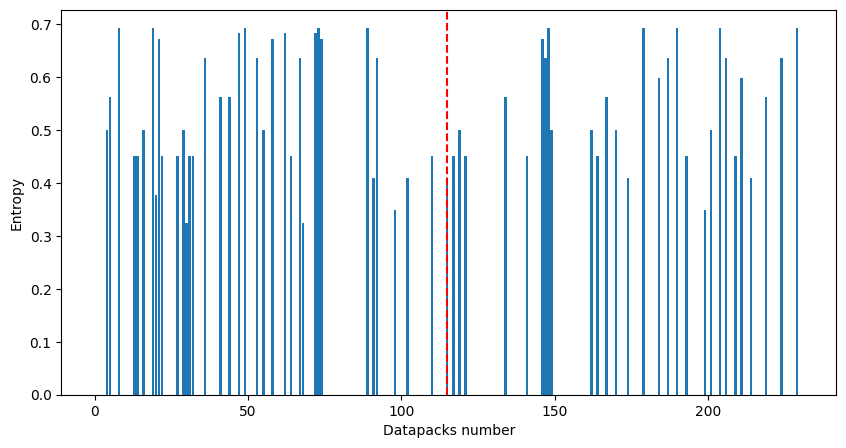

In [22]:
import scipy
import matplotlib.pyplot as plt

probs_entropies = []

for prob in probs:
    probs_entropies.append(scipy.stats.entropy(prob))

probs_dict = sorted(dict(zip(datapacks_names, probs_entropies)).items())
x, y = zip(*probs_dict)

plt.figure(figsize=(10, 5))
plt.bar(x, y)
plt.ylabel("Entropy")
plt.xlabel("Datapacks number")
plt.axvline(len(patients_ours), color = "red", linestyle="--")
plt.show()

In [8]:
cataract_packs = []
non_cataract_packs = []

for pack, label in labeled_packs:
    if label == cataract_label:
        cataract_packs.append(pack)
    elif label == non_cataract_label:
        non_cataract_packs.append(pack)

print(len(cataract_packs))
print(len(non_cataract_packs))

115
41


In [9]:
trainval_set_prop = 0.9

random.seed("cataract")
random.shuffle(cataract_packs)
random.shuffle(non_cataract_packs)

trainval_cataracts_size = int(trainval_set_prop * len(cataract_packs))
trainval_cataracts = cataract_packs[:trainval_cataracts_size]

trainval_non_cataracts_size = int(trainval_set_prop * len(non_cataract_packs))
trainval_non_cataracts = non_cataract_packs[:trainval_non_cataracts_size]

test_cataracts = cataract_packs[trainval_cataracts_size:]
test_non_cataracts = non_cataract_packs[trainval_non_cataracts_size:]

trainval_set = trainval_cataracts + trainval_non_cataracts
test_set = test_cataracts + test_non_cataracts

print(trainval_cataracts_size)
print(trainval_non_cataracts_size)
print(len(test_cataracts))
print(len(test_non_cataracts))

103
36
12
5


In [10]:
import json

split = {
    "trainvalSet": {
        "cataract": trainval_cataracts,
        "nonCataract": trainval_non_cataracts,
    },
    "testSet": {
        "cataract": test_cataracts,
        "nonCataract": test_non_cataracts,
    },
}

with open("split.json", "w+") as f:
    json.dump(split, f, indent=4)